# 定理3　抽象的共有 TCZ 収束定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理3は何を言っているのか

### 原文の主張

定理2では、複数の主体が「ズレ料金」を払って **共有の谷** にそろいました。ただし谷が遠いと共有の谷そのものが無い、という但し書きがありました。
定理3は、そこに **「より高い抽象度の共通の世界」への引き力** を足します。

各主体 $i$ は、自分の考える世界 $W_i$（ある概念の集まり）をもっています。概念の集まりは包含関係で高低がつき、複数の世界を **全部包む最小の世界** を **LUB（最小上界）** $L^*=\bigvee_i W_i$ と呼びます。

各主体の評価に、**抽象残差**（LUB $L^*$ への未達度）$\mathcal A_i$ を重み $\eta_i>0$ で足します。

$$
\pi_i=\arg\min_{u_i(\cdot)}\int\Bigl(V_{0,i}+\sum_j\gamma_{ij}S_{ij}+\eta_i\,\mathcal A_i\Bigr)ds
\quad\Longrightarrow\quad
\bigl\|\iota\bigl(\varphi_i(x_i(t))\bigr)-\iota(L^*)\bigr\|\longrightarrow0 .
$$

* $\varphi_i$：状態 $x_i$ から「いま、どの高さ（どの世界）で考えているか」への写像。
* $\iota$：世界（束の要素）を **数のベクトル** に写す順序埋め込み。大小関係を保ち、別々の世界は別のベクトルに写ります。
* $\mathcal A_i(x_i)=\|\iota(\varphi_i(x_i))-\iota(L^*)\|^2$。LUB に達すると $0$。

**前提：** 定理2の前提（グラフの連結など）＋ 抽象残差 $\mathcal A_i$ が $L^*=\bigvee W_i$ で $0$ になること。
**型の修正（原文）：** 状態 $x$ と束の要素 $L^*$ を直接比べてはいけません。必ず $\varphi$ と $\iota$ を通して、同じ「型」の量どうしを比べます。

### 証明の心

$\Phi_2$ に $\sum_i\eta_i\mathcal A_i$ を足した $\Phi_3$ が、また補題0の下降条件を満たします。$\Phi_3\to0$ の中に $\mathcal A_i\to0$（全員の思考の高さが屋根 $L^*$ にそろう）が含まれています。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 束 $\mathbb L$ | $\{0,1,2\}$ の部分集合（ビットで表す） | 整数 `0b001` など |
| $\vee$ | 世界を包む結合（和集合＝ビット OR） | `Lstar_bits \|= Wi` |
| $W_i$ | 主体 $i$ の世界。最初は別々の概念 $\{0\},\{1\},\{2\}$ | `W = [0b001, 0b010, 0b100]` |
| $L^*=\bigvee W_i$ | LUB。ここでは $\{0,1,2\}$ | `Lstar_bits = 0b111` |
| $\iota$ | 世界を $\{0,1\}^3$ のベクトルに写す（指示ベクトル） | `iota` |
| $x_i\in\mathbb R^3$ | 状態（連続版）。各成分は「その概念を含む度合い」 | `x[i]`、$\varphi_i(x)=x$ |
| $\mathcal A_i$ | 抽象残差 $\|x_i-\iota(L^*)\|^2$ | `A` |
| $S_{ij}$ | 主体 $i,j$ のズレ $\|x_i-x_j\|^2$ | `S` |
| $\eta,\gamma$ | 抽象残差・ズレ料金の重み（$\eta=1,\ \gamma=0.5$） | `eta, gamma` |

## 2. なぜこれが「定理3の例」と言えるのか

* **3人が別々の概念しか知らない。** 主体 0 は概念 0 だけ、主体 1 は概念 1 だけ、主体 2 は概念 2 だけを知っています（$x_i(0)=\iota(W_i)=e_i$）。3人を **全員包む最小の世界** は $L^*=\{0,1,2\}$（3概念すべて）です。
* **2つの力が働く。** 互いのズレを減らす力（$\gamma$）と、LUB $L^*$ へ引き上げる力（$\eta$）。コードの `g` はその合計 $\Phi_3=\gamma\sum_{i<j}S_{ij}+\eta\sum_i\mathcal A_i$ の勾配です。
* **見どころ：LUB は「平均」ではない。** もし抽象残差の項（$\eta$）が無ければ、勾配流は3人の状態の **和** を保存するので、全員が初期値の **平均** $(\tfrac13,\tfrac13,\tfrac13)$ に落ち着きます（これは対称性からの推論で、このコードが確かめているわけではありません）。
  $\eta>0$ があると、落ち着き先は平均ではなく **全概念を含む $(1,1,1)$ = LUB** になります。これが「谷の底が上へ持ち上がる」という原文の言い方の中身です。

## 3. シミュレーション

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

W = [0b001, 0b010, 0b100]                      # 各主体の世界 (ビット = 概念の有無)
Lstar_bits = 0
for Wi in W: Lstar_bits |= Wi                  # L* = ∨ W_i
iota = lambda b: np.array([(b >> k) & 1 for k in range(3)], float)   # 順序埋め込み ι
L = iota(Lstar_bits)

eta, gamma, dt = 1.0, 0.5, 0.01
x = np.array([iota(b) for b in W])             # x_i(0) = ι(W_i)
hist = []
for _ in range(600):
    A = ((x - L)**2).sum(axis=1)                          # 抽象残差 A_i
    S = sum(((x[i] - x[j])**2).sum() for i in range(3) for j in range(i + 1, 3))
    hist.append((A.copy(), S, x.copy()))
    # Φ3 = γ ΣS_ij + η ΣA_i の勾配流
    g = 2 * eta * (x - L)
    for i in range(3):
        for j in range(3):
            if i != j: g[i] += 2 * gamma * (x[i] - x[j])
    x = x - dt * 2 * g

$\Phi_3=\gamma\sum_{i<j}S_{ij}+\eta\sum_i\mathcal A_i$ の勾配流を、時間刻み $dt=0.01$ で 600 ステップ（時間にして $6$）進めました。

## 4. 図を読む

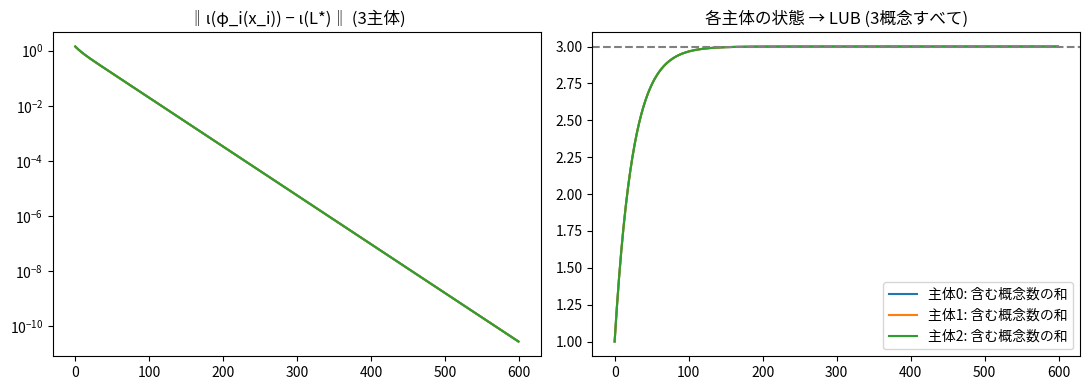

In [2]:
# %% 可視化
Aall = np.array([h[0] for h in hist]); traj = np.array([h[2] for h in hist])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(np.sqrt(Aall)); ax[0].set_title("‖ι(φ_i(x_i)) − ι(L*)‖ (3主体)")
for i in range(3): ax[1].plot(traj[:, i, :].sum(axis=1), label=f"主体{i}: 含む概念数の和")
ax[1].axhline(3, ls="--", c="gray"); ax[1].set_title("各主体の状態 → LUB (3概念すべて)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 左：$\|\iota(\varphi_i(x_i))-\iota(L^*)\|$（対数軸）

3本の線は **完全に重なって1本に見えます**（3人の初期状態が対称だからです）。
縦軸が対数なので、**直線は指数減衰** を意味します。最初の約 $1.4$ から 600 ステップ後の約 $3\times10^{-11}$ まで、ずっと同じ傾きで下がっています。傾きは概ね $e^{-4t}$（$t$ は時間）に相当し、後述の厳密解の主な減衰率 $4\eta$ と合っています。
これが定理3の結論 $\|\iota(\varphi_i(x_i(t)))-\iota(L^*)\|\to0$ の **速度つき** の姿です。

### 右：各主体の「含む概念数の和」

各主体の状態ベクトルの成分の和を描いています。最初は誰も1概念だけ知っているので **1**。それが約 100 ステップで **3**（灰色の破線＝全概念を含む LUB）へ上がります。
3本はやはり重なっています。**全員が $\{0,1,2\}$ へ向かう** ことが読み取れます。
もし平均に落ち着くのなら、和は $1$ のままのはずです（平均 $(\tfrac13,\tfrac13,\tfrac13)$ の成分の和は $1$）。実際には $3$ に上がっているので、この例は「平均ではなく LUB」を示しています。

## 5. 数値確認

In [3]:
# %% 数値確認
print("L* =", bin(Lstar_bits), " 最終残差 =", np.sqrt(Aall[-1]).max())
assert np.sqrt(Aall[-1]).max() < 1e-3
assert np.allclose(x, L, atol=1e-3)             # 平均 (1/3,1/3,1/3) ではなく LUB に収束

L* = 0b111  最終残差 = 2.772912193765099e-11


最終残差は約 $2.8\times10^{-11}$。`assert` は、(i) 残差が $10^{-3}$ 未満、(ii) 最終状態が平均ではなく LUB $(1,1,1)$ に近い、の2点を確認しています。

## 6. 厳密解との比較

In [4]:
# %% 厳密解との比較 (Lean が使う閉形式)
tt = dt * len(hist)
a_, b_ = np.exp(-4 * eta * tt), np.exp(-4 * (eta + 3 * gamma) * tt)
exact = np.array([[1 - 2 / 3 * a_ + (2 / 3 if i == k else -1 / 3) * b_ for k in range(3)] for i in range(3)])
print("Euler と厳密解の差(最大):", np.abs(x - exact).max())
assert np.abs(x - exact).max() < 2e-2

Euler と厳密解の差(最大): 9.798495348434244e-12


この流れには閉じた形の解があります（$\eta=1,\ \gamma=0.5,\ x_i(0)=e_i$）。

$$
x_{ik}(t)=1-\tfrac23e^{-4\eta t}+\bigl(\delta_{ik}-\tfrac13\bigr)e^{-4(\eta+3\gamma)t},
\qquad
\Phi_3(t)=4\eta\,e^{-8\eta t}+2(\eta+3\gamma)\,e^{-8(\eta+3\gamma)t}.
$$

ここで $\delta_{ik}$ はクロネッカーのデルタ（$i=k$ なら 1、それ以外は 0）です。
第1項 $1-\tfrac23e^{-4\eta t}$ は **全員共通** で $1$（=LUB の成分）へ近づく部分、第2項は **主体ごとの違い**（最初の $e_i$ からの偏り）が速く消える部分です（減衰率 $4(\eta+3\gamma)=10$ のほうが速い）。
Euler 法の結果と厳密解の差は最大約 $10^{-11}$ で、離散化の誤差は無視できる大きさです。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「空」への階梯の一段目。** 原文は LUB の上にさらに高い屋根があり、はしごのてっぺん $\top$ を **空（くう）** と読む、と説明しています（定理22）。定理3は、その階段の **最初の一段**：バラバラな世界を **消さずに全部包む** 共通の世界へ集団が引き上げられる、という内容です。
* **平均ではないことの意味。** 平均は「みんなの真ん中」で、各自が知っていたものを薄めます。LUB は「みんなの知っていたものを全部含む」世界で、誰の世界も捨てていません。原文の言う「谷の底が、上へ持ち上がる」はこの違いのことです。
* ここで $\vee$（包む）という操作が使われているのは、定理22の「消さずに包む（$u_{n+1}=u_n\vee v_{n+1}$）」更新則と同じ精神だからです。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem3_LubConsensus.lean`（一般定理 `AbstractSharedSystem.theorem3_two_distances_tendsto_of_ac_ae_descent`）。

| | 内容 | 状態 |
| --- | --- | --- |
| 勾配流 $\dot x_i=-2\nabla_{x_i}\Phi_3$（$\eta=1,\gamma=\tfrac12$、$x_i(0)=e_i$） | 厳密解（上の閉形式）、$\Phi_3$ の閉形式、絶対連続・a.e. 下降 $\Phi_3'\le-8\eta\Phi_3$・誤差境界 $\operatorname{dist}^2\le\Phi_3/\eta$ | 証明済 |
| LUB $=(1,1,1)$（平均ではない） | 束を $\mathbb L=\mathrm{Fin}\,3\to[0,1]$（ファジー集合）として扱い、一般定理から距離の指数収束と極限 | 証明済（**連続時間**） |
| Python の Euler 離散化と厳密解の一致 | 数値のみ（上の差 $\sim10^{-11}$） | 未証明 |

* Lean の束は **ファジー集合の束** $\mathrm{Fin}\,3\to[0,1]$ です。Python の連続版状態（各成分が「含む度合い」）と同じ設定です。
* 勾配流の時間スケールは $\dot x=-2\nabla\Phi_3$ です（コードの `x - dt*2*g` と同じ）。